# Corpus Description and Politician Agendas

This notebook produces the figures and tables of Chapter 6 of the TFM. It
loads the cleaned, LLM-classified dataset (`classified_all_tweets_final_v2_clean.csv`)
and characterizes the corpus from three angles: global label distributions,
volume and temporal coverage by political actor, and per-actor agendas in
topic and stance.

All exploratory data work (cleaning, validation of valid values, handling
of the `confidence` column, definition of the *common period*) lives in the
companion notebook `EdaDataset.ipynb`. The present notebook assumes that
work has been done and consumes its output.


## Setup


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

TOPIC_LABELS = [
    'Economy and Employment',
    'Welfare, Housing and Social Policy',
    'National Politics and Governance',
    'International Affairs',
    'Immigration and Security',
    'Rights and Equality',
    'Other',
]
STANCE_LABELS = ['Against', 'Unclear', 'Neutral', 'In favor']
STANCE_COLORS = {
    'Against':  '#C44E52',
    'Unclear':  '#8C8C8C',
    'Neutral':  '#DDA85C',
    'In favor': '#4C72B0',
}


In [31]:
df = pd.read_csv('classified_all_tweets_final_v2_clean.csv', parse_dates=['date'])
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

print(f'Tweets: {len(df):,}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Politicians: {sorted(df["politician"].unique())}')


Tweets: 11,866
Date range: 2022-04-23 → 2026-04-22
Politicians: ['NunezFeijoo', 'Santi_ABASCAL', 'Yolanda_Diaz_', 'sanchezcastejon']


### Common period

The four actors do not share the same temporal coverage (notably, Yolanda
Díaz left X in January 2025). For any cross-actor comparison, results
are reported on a *common period*. The variable `df_common` below holds the restricted
sample used for those comparisons; `df` continues to hold the full corpus.


In [32]:
# Common period: from the latest first-tweet date to the earliest last-tweet date
common_start = df.groupby('politician')['date'].min().max()
common_end   = df.groupby('politician')['date'].max().min()

df_common = df[(df['date'] >= common_start) & (df['date'] <= common_end)].copy()

print(f'Common period: {common_start.date()} → {common_end.date()}')
print(f'Tweets in common period: {len(df_common):,} '
      f'({len(df_common)/len(df)*100:.1f}% of full corpus)')


Common period: 2022-04-23 → 2025-01-21
Tweets in common period: 9,908 (83.5% of full corpus)


## Global topic and stance distributions

The two bar charts below summarize the share of each topic and each stance
label in the full corpus. They establish the baseline against which all
per-actor and temporal breakdowns will be read.


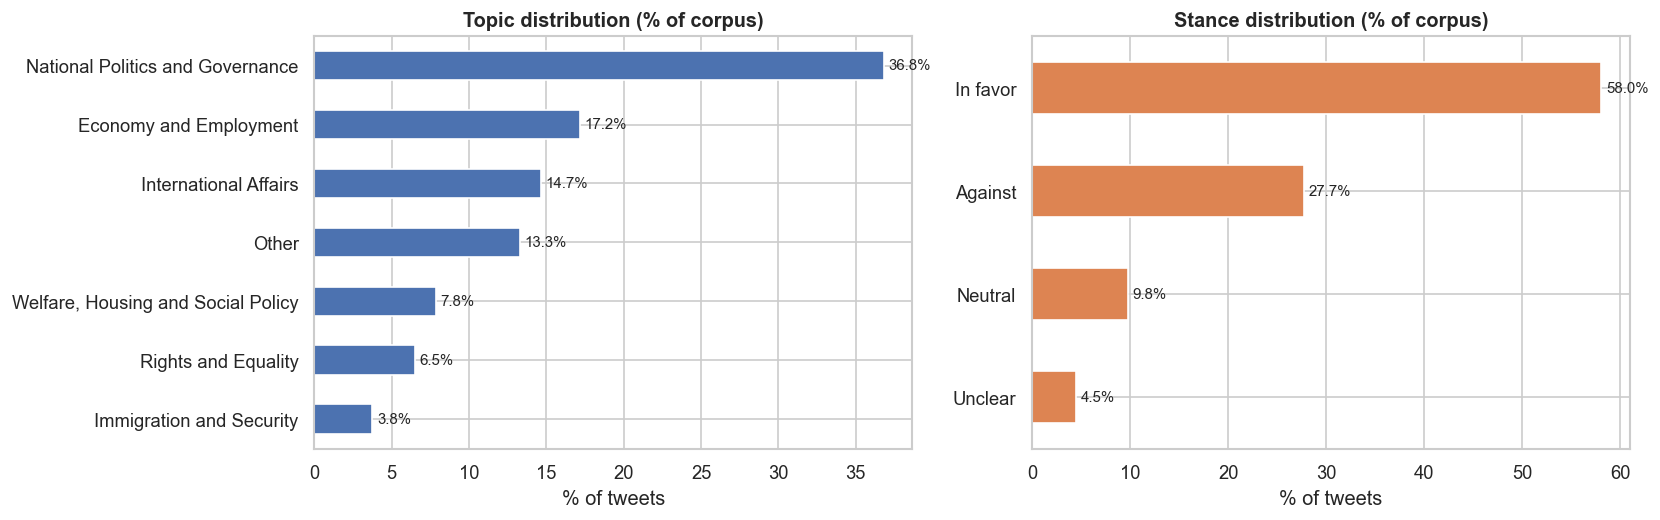

In [33]:
topic_distribution = (df['topic'].value_counts(normalize=True) * 100).round(2).rename('percent').to_frame()
topic_distribution['count'] = df['topic'].value_counts()

stance_distribution = (df['stance'].value_counts(normalize=True) * 100).round(2).rename('percent').to_frame()
stance_distribution['count'] = df['stance'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

topic_distribution['percent'].sort_values().plot.barh(
    ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Topic distribution (% of corpus)', fontweight='bold')
axes[0].set_xlabel('% of tweets'); axes[0].set_ylabel('')
for i, v in enumerate(topic_distribution['percent'].sort_values()):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

stance_distribution['percent'].sort_values().plot.barh(
    ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Stance distribution (% of corpus)', fontweight='bold')
axes[1].set_xlabel('% of tweets'); axes[1].set_ylabel('')
for i, v in enumerate(stance_distribution['percent'].sort_values()):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout(); plt.show()


The figure summarizes the global distribution of topic and stance labels in the classified corpus. The topic distribution shows that the conversation is dominated by National Politics and Governance, which represents 36.8% of all tweets. This confirms that the corpus is strongly centered on institutional politics, government activity, parties, laws, elections and political conflict.

The second most frequent category is Economy and Employment, with 17.2% of the corpus, followed by International Affairs with 14.7%. These two categories form the main secondary thematic blocks. Their presence suggests that, although national politics is the central axis of the discussion, economic issues and international events also play an important role in the communication of Spanish political actors.

The category Other accounts for 13.3% of the corpus. This indicates that a relevant share of tweets could not be clearly assigned to one of the six substantive policy categories. This is expected in social media data, where politicians also post about personal events, symbolic messages, campaign communication, commemorations, media appearances or ambiguous content.

The remaining categories have lower frequencies. Welfare, Housing and Social Policy represents 7.8% of the corpus, Rights and Equality represents 6.5%, and Immigration and Security represents 3.8%. These categories are present in the debate, but they appear less frequently than national politics, economic issues and international affairs. This lower volume should be considered when interpreting actor-level or temporal results, since small categories may produce less stable patterns.

The stance distribution shows a clear predominance of In favor, which represents 58.0% of the corpus. Against accounts for 27.7%, while Neutral and Unclear represent 9.8% and 4.5%, respectively. This means that most tweets contain a supportive or affirmative stance, often related to policy promotion, institutional communication, political achievements or endorsement of a position.

The relatively high share of In favor tweets may reflect the nature of the corpus, which is based on tweets published by political actors themselves. These actors often use social media to promote their own agenda, defend their actions, support their party positions or present policy proposals. At the same time, the presence of 27.7% Against tweets shows that criticism and opposition are also central components of the discussion.

Neutral and Unclear labels represent a smaller part of the corpus. This suggests that the LLM classification usually detected an identifiable stance, while only a minority of tweets were descriptive, ambiguous, ironic, incomplete or difficult to classify. However, these categories remain important because they reduce the risk of forcing a stance label when the tweet does not clearly express one.

In short, the corpus is mainly structured around national political debate and supportive political communication, with economy and international affairs as important secondary axes. The distribution also shows a class imbalance that must be taken into account in later analyses, especially in per-topic, per-actor and temporal comparisons.

## Volume and temporal coverage by actor


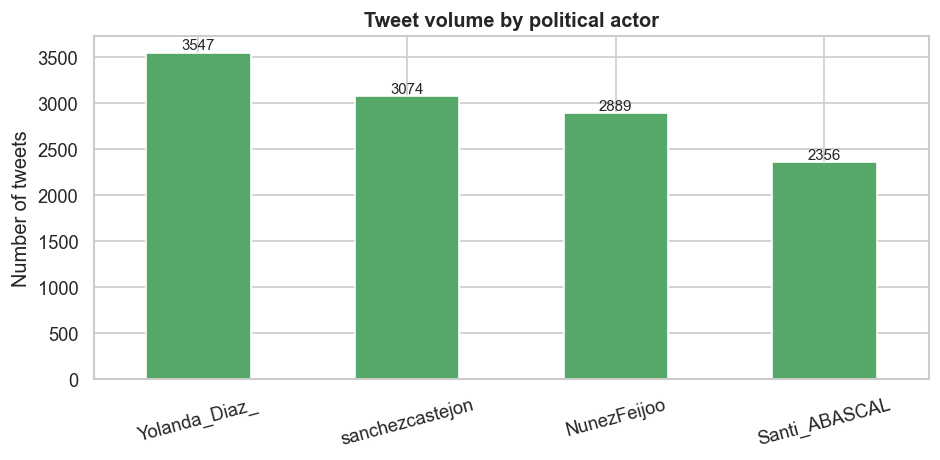

In [34]:
politician_counts = df['politician'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
politician_counts.plot.bar(ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Tweet volume by political actor', fontweight='bold')
ax.set_ylabel('Number of tweets'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(politician_counts):
    ax.text(i, v + max(politician_counts)*0.01, str(v),
            ha='center', fontsize=9)
plt.tight_layout(); plt.show()


The figure shows the number of classified tweets available for each political actor in the corpus. The distribution is relatively balanced, although not identical across actors. Yolanda Diaz has the highest number of tweets, with 3,547 observations, followed by Sanchez with 3,074, Feijoo with 2,889 and Abascal with 2,356.

This means that all four actors are sufficiently represented in the corpus, which allows actor-level comparisons in later sections. However, the differences in volume should still be considered when interpreting raw counts. For example, Yolanda Diaz contributes around 1,200 more tweets than Abascal, so direct comparisons based only on absolute frequencies could overrepresent the activity of more prolific accounts.

For this reason, later actor-level analyses should rely mainly on proportions rather than raw counts. Topic shares, stance shares and normalized actor-topic distributions provide a fairer basis for comparison because they control for differences in the total number of tweets per politician.

The figure also shows that the corpus is not dominated by a single actor. Although Yolanda Diaz is the most represented account, the four politicians contribute enough data to support comparative analysis of political agendas, stance patterns and temporal dynamics.

In [35]:
coverage = (df.groupby('politician')
              .agg(n_tweets=('tweet_id','count'),
                   first_tweet=('date','min'),
                   last_tweet=('date','max'))
              .sort_values('n_tweets', ascending=False))
coverage


,n_tweets,first_tweet,last_tweet
politician,,,
Yolanda_Diaz_,3547,2022-04-23,2025-01-21
sanchezcastejon,3074,2022-04-23,2026-04-22
NunezFeijoo,2889,2022-04-23,2026-04-22
Santi_ABASCAL,2356,2022-04-23,2026-04-22


### Monthly timeline (annotated)

The figure overlays the monthly tweet volume of each actor with key
political events of the corpus window. Vertical dashed lines mark events;
events that fall outside the corpus range are not displayed.


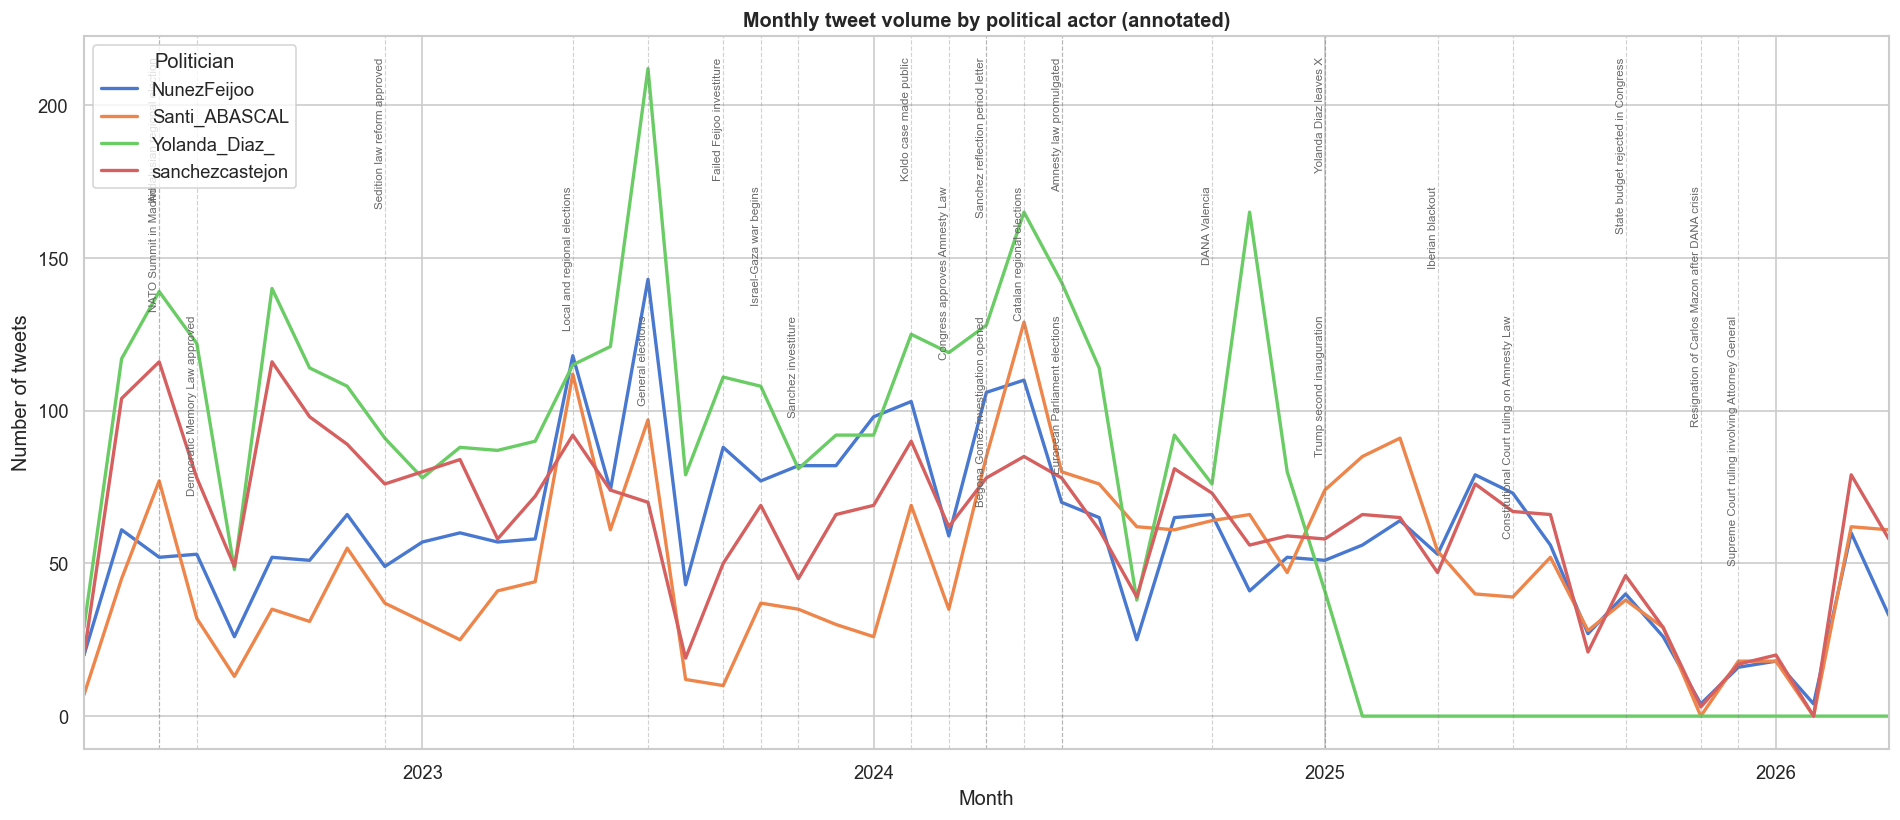

In [36]:
# --- Construcción del pivot mensual por actor ---
monthly_actor_counts = (df.groupby(['month', 'politician'])
                          .size().reset_index(name='n_tweets'))

monthly_actor_pivot = monthly_actor_counts.pivot(
    index='month', columns='politician', values='n_tweets').fillna(0)

if hasattr(monthly_actor_pivot.index, 'to_timestamp'):
    monthly_actor_pivot.index = monthly_actor_pivot.index.to_timestamp()
else:
    monthly_actor_pivot.index = pd.to_datetime(monthly_actor_pivot.index.astype(str))

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 7))
monthly_actor_pivot.plot(ax=ax, linewidth=2)

# --- Eventos ---
events = {
    # --- 2022 ---
    '2022-06-19': 'Andalusian regional election',
    '2022-06-29': 'NATO Summit in Madrid',
    '2022-07-14': 'Democratic Memory Law approved',
    '2022-12-15': 'Sedition law reform approved',
    # --- 2023 ---
    '2023-05-28': 'Local and regional elections',
    '2023-07-23': 'General elections',
    '2023-09-29': 'Failed Feijoo investiture',
    '2023-10-07': 'Israel-Gaza war begins',
    '2023-11-16': 'Sanchez investiture',
    # --- 2024 ---
    '2024-02-21': 'Koldo case made public',
    '2024-03-14': 'Congress approves Amnesty Law',
    '2024-04-17': 'Begona Gomez investigation opened',
    '2024-04-24': 'Sanchez reflection period letter',
    '2024-05-12': 'Catalan regional elections',
    '2024-06-09': 'European Parliament elections',
    '2024-06-11': 'Amnesty law promulgated',
    '2024-10-29': 'DANA Valencia',
    # --- 2025 ---
    '2025-01-20': 'Trump second inauguration',
    '2025-01-21': 'Yolanda Diaz leaves X',
    '2025-04-28': 'Iberian blackout',
    '2025-06-26': 'Constitutional Court ruling on Amnesty Law',
    '2025-09-18': 'State budget rejected in Congress',
    '2025-11-15': 'Resignation of Carlos Mazon after DANA crisis',
    '2025-12-03': 'Supreme Court ruling involving Attorney General',
}

# --- Filtrar a la ventana visible y ordenar cronologicamente ---
sorted_events = sorted(events.items())
xmin, xmax = monthly_actor_pivot.index.min(), monthly_actor_pivot.index.max()
visible = [(d, lbl) for d, lbl in sorted_events
           if xmin <= pd.to_datetime(d) <= xmax]

# --- Etiquetas a tres alturas alternadas ---
ymax = ax.get_ylim()[1]
levels = [0.97, 0.78, 0.59]   # tres niveles para evitar solapamiento

for i, (d, label) in enumerate(visible):
    d_ts = pd.to_datetime(d)
    y_pos = ymax * levels[i % len(levels)]
    ax.axvline(d_ts, color='grey', linestyle='--', alpha=0.35, linewidth=0.7)
    ax.text(d_ts, y_pos, label,
            rotation=90, va='top', ha='right',
            fontsize=7, color='dimgrey')

ax.set_title('Monthly tweet volume by political actor (annotated)',
             fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Number of tweets')
ax.legend(title='Politician', loc='upper left')
plt.tight_layout(); plt.show()

The figure shows the monthly number of classified tweets for each political actor. This visualization is useful to assess the temporal coverage of the corpus and to identify periods of higher or lower activity before moving to the thematic analysis.

The four actors show substantial activity during most of the common period, but their posting volume is not constant over time. Several peaks appear around relevant political moments, such as elections, investiture processes, parliamentary debates or major political controversies. This suggests that tweet volume is partly event-driven: political actors tend to publish more during periods of higher political salience.

Yolanda Diaz shows the highest activity during several months of the 2022-2024 period, with particularly visible peaks before 2025. However, her series drops to zero after January 2025, which reflects the fact that she leaves X during the observed period. This has an important methodological implication: analyses comparing all four actors should preferably use the common period, because including the full 2025-2026 window would create an artificial imbalance between Yolanda Diaz and the other politicians.

Sanchez, Feijoo and Abascal continue to show activity after January 2025, although tweet volumes fluctuate considerably. In some later months, activity decreases sharply for all three actors, which may reflect either lower posting intensity, data collection limits, or periods with fewer relevant tweets available in the corpus. For this reason, later temporal analyses should be interpreted together with the volume of observations available in each month.

The figure also shows that raw monthly counts are useful for describing activity, but they are not always ideal for comparing political agendas. A politician with more tweets in a given month may appear more prominent simply because of higher posting volume. Therefore, later topic-evolution analyses should use normalized measures, such as monthly topic shares, when the objective is to compare thematic priorities across actors or across time.

In short, this plot confirms that the corpus has broad temporal coverage and enough activity for longitudinal analysis, but it also shows that actor activity is uneven. The drop in Yolanda Diaz's activity after January 2025 is especially relevant and justifies the use of a common-period subset in the actor-level and network analyses.

## Topic agendas by political actor

The two heatmaps below show, for each actor, the percentage of tweets
assigned to each of the seven topic categories. The first uses the full
corpus; the second restricts the data to the common period. The matrices
provide the empirical basis for the agenda-divergence metric reported in
the next subsection.


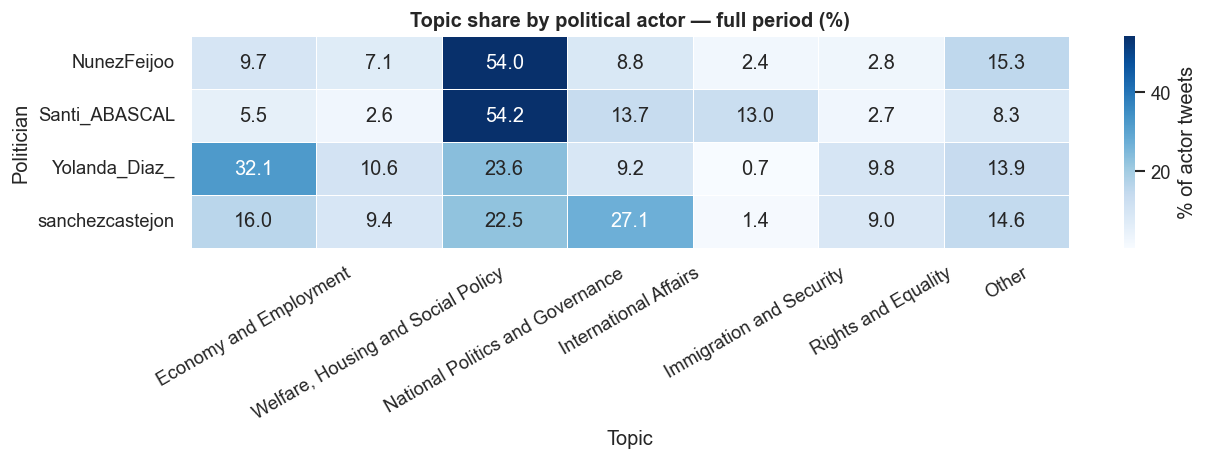

In [37]:
actor_topic_percent = pd.crosstab(
    df['politician'], df['topic'], normalize='index') * 100
actor_topic_percent = actor_topic_percent.reindex(columns=TOPIC_LABELS)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(actor_topic_percent.round(1),
            annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of actor tweets'}, ax=ax)
ax.set_title('Topic share by political actor — full period (%)', fontweight='bold')
ax.set_xlabel('Topic'); ax.set_ylabel('Politician')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


The heatmap shows the percentage distribution of topics within each politician's tweets during the full period. Each row sums to 100%, so the figure compares thematic priorities independently of the total number of tweets published by each actor.

The most visible pattern is the strong concentration of Núñez Feijóo and Santiago Abascal in National Politics and Governance. This category represents 54.0% of Feijóo's tweets and 54.2% of Abascal's tweets. This indicates that both opposition actors focus a large part of their communication on government activity, institutional conflict, party competition, laws and national political debate.

Despite this similarity, Feijóo and Abascal also differ in their secondary topics. Abascal gives more weight to Immigration and Security, with 13.0% of his tweets, compared with only 2.4% for Feijóo. He also has a higher share of International Affairs, with 13.7%. This suggests that Abascal's agenda combines national political confrontation with a stronger emphasis on immigration, security and international issues. Feijóo, in contrast, has a larger share of Other (15.3%) and slightly more attention to Economy and Employment (9.7%).

Yolanda Díaz presents a clearly different thematic profile. Her strongest category is Economy and Employment, which represents 32.1% of her tweets. This is consistent with her political role and with a communication strategy focused on labour issues, employment, wages and socio-economic policy. She also shows relevant shares in National Politics and Governance (23.6%), Other (13.9%), Welfare, Housing and Social Policy (10.6%) and Rights and Equality (9.8%). Compared with Feijóo and Abascal, her agenda is less concentrated in national political conflict and more oriented towards socio-economic and rights-related topics.

Sánchez also shows a more diversified profile. His largest category is International Affairs, with 27.1% of his tweets, followed by National Politics and Governance (22.5%), Economy and Employment (16.0%) and Other (14.6%). The strong presence of International Affairs is consistent with his role as head of government, since this position involves diplomatic activity, European politics, international summits and foreign policy communication.

The lowest values also provide useful information. Immigration and Security has very low shares for Yolanda Díaz (0.7%) and Sánchez (1.4%), while it is much more visible for Abascal. Rights and Equality is more present in the agendas of Yolanda Díaz (9.8%) and Sánchez (9.0%) than in those of Feijóo and Abascal, both below 3%. This indicates that some topics are strongly actor-dependent.

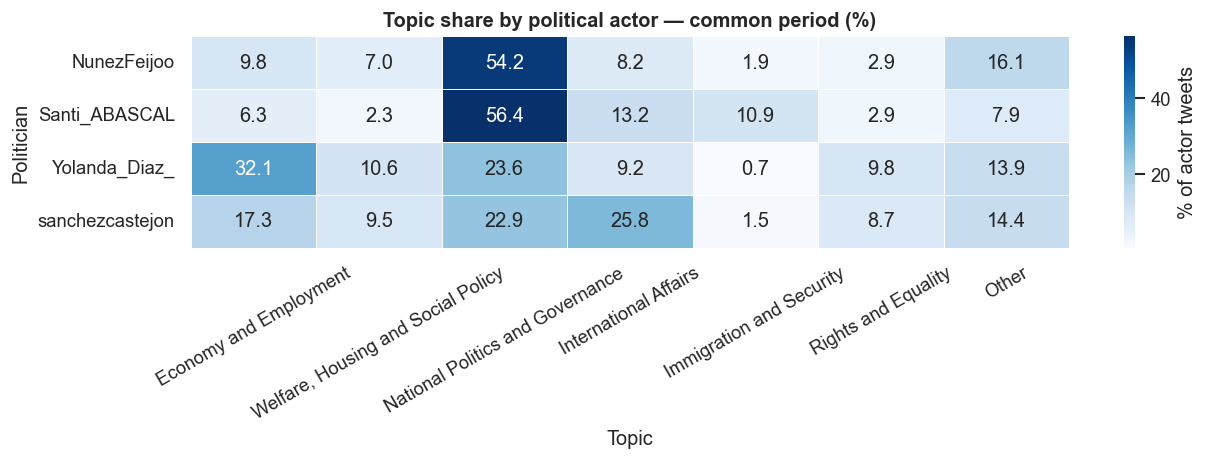

In [38]:
actor_topic_percent_common = pd.crosstab(
    df_common['politician'], df_common['topic'], normalize='index') * 100
actor_topic_percent_common = actor_topic_percent_common.reindex(columns=TOPIC_LABELS)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(actor_topic_percent_common.round(1),
            annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of actor tweets'}, ax=ax)
ax.set_title('Topic share by political actor — common period (%)', fontweight='bold')
ax.set_xlabel('Topic'); ax.set_ylabel('Politician')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


This heatmap repeats the actor-topic comparison using only the common period shared by all four political actors. This is important because Yolanda Díaz leaves X in January 2025, while the other actors continue to publish after that date. Therefore, the common-period version avoids comparing actors over different temporal windows.

The comparison between the full-period and common-period heatmaps shows that the main thematic patterns remain highly stable. Núñez Feijóo and Santiago Abascal continue to concentrate most of their communication in National Politics and Governance. In the full period, this topic represented 54.0% of Feijóo's tweets and 54.2% of Abascal's tweets. In the common period, the values are very similar: 54.2% for Feijóo and 56.4% for Abascal. This confirms that their strong focus on national political debate is not an artifact of the extended time window.

Yolanda Díaz does not change between the two heatmaps because her activity ends within the common period. Her profile remains centered on Economy and Employment, with 32.1% of her tweets, followed by National Politics and Governance with 23.6%. This reinforces the interpretation of her agenda as more socio-economic and labour-oriented.

Sánchez also remains broadly stable. His strongest topic continues to be International Affairs, although it decreases slightly from 27.1% in the full period to 25.8% in the common period. Economy and Employment increases from 16.0% to 17.3%, while National Politics and Governance changes only slightly, from 22.5% to 22.9%. These small differences indicate that his thematic profile is not strongly altered by restricting the analysis to the common period.

Some secondary changes appear for the opposition actors. Abascal's share of National Politics and Governance increases from 54.2% to 56.4%, while Immigration and Security decreases from 13.0% to 10.9%. Feijóo's Other category increases slightly from 15.3% to 16.1%, while International Affairs decreases from 8.8% to 8.2%. These changes are modest and do not alter the main interpretation.



### Agenda divergence between actors

The Jensen–Shannon distance between the topic distributions of two
actors summarizes how different their agendas are. The metric is bounded
in [0, 1], with 0 indicating identical agendas and 1 indicating
maximally disjoint ones.


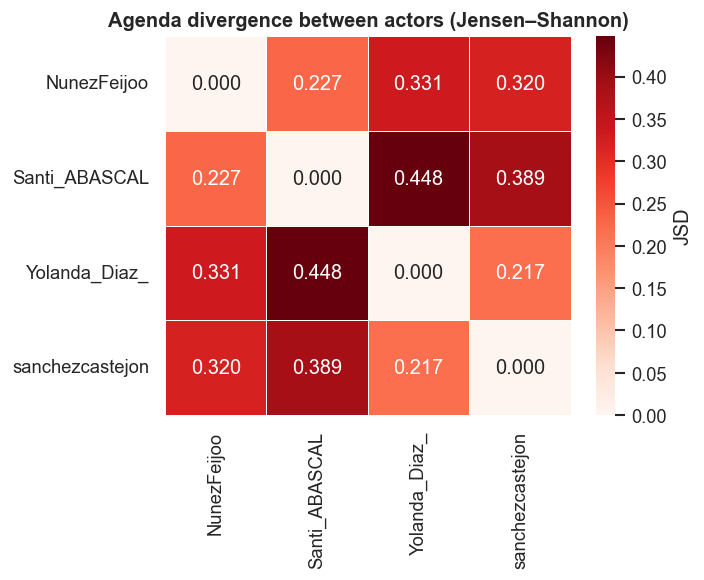

Pairs ranked by agenda similarity (lower = more similar):
      Actor A         Actor B      JSD
Yolanda_Diaz_ sanchezcastejon 0.216961
  NunezFeijoo   Santi_ABASCAL 0.227416
  NunezFeijoo sanchezcastejon 0.319848
  NunezFeijoo   Yolanda_Diaz_ 0.331135
Santi_ABASCAL sanchezcastejon 0.389009
Santi_ABASCAL   Yolanda_Diaz_ 0.447758


In [39]:
actors = actor_topic_percent_common.index.tolist()
P = actor_topic_percent_common.values / 100

jsd_matrix = pd.DataFrame(index=actors, columns=actors, dtype=float)
for i, a in enumerate(actors):
    for j, b in enumerate(actors):
        jsd_matrix.loc[a, b] = jensenshannon(P[i], P[j], base=2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(jsd_matrix.astype(float),
            annot=True, fmt='.3f', cmap='Reds',
            linewidths=0.5, linecolor='white',
            vmin=0, cbar_kws={'label': 'JSD'}, ax=ax)
ax.set_title('Agenda divergence between actors (Jensen–Shannon)', fontweight='bold')
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(actors)):
    for j in range(i+1, len(actors)):
        pairs.append((actors[i], actors[j], jsd_matrix.iloc[i, j]))
pairs_df = (pd.DataFrame(pairs, columns=['Actor A', 'Actor B', 'JSD'])
              .sort_values('JSD')
              .reset_index(drop=True))
print('Pairs ranked by agenda similarity (lower = more similar):')
print(pairs_df.to_string(index=False))


The heatmap shows the thematic divergence between political actors using Jensen-Shannon distance. This metric compares the topic distribution of each pair of politicians. Lower values indicate more similar agendas, while higher values indicate greater thematic divergence.

The results show two clearly closer pairs. The lowest distance appears between Sánchez and Yolanda Díaz, with a JSD of 0.217. This means that their topic distributions are the most similar in the corpus. This is consistent with the previous heatmaps, where both actors showed more diversified agendas and greater attention to socio-economic, welfare, rights-related and institutional topics.

The second closest pair is Núñez Feijóo and Santiago Abascal, with a JSD of 0.227. This indicates that the two opposition actors have very similar thematic agendas. Their similarity is mainly explained by the strong weight of National Politics and Governance in both profiles, which represents more than half of their tweets.

The highest divergence appears between Santiago Abascal and Yolanda Díaz, with a JSD of 0.448. This is the most distant pair in the matrix. The result reflects their very different thematic priorities: Abascal is much more focused on National Politics and Governance, Immigration and Security and International Affairs, while Yolanda Díaz gives more weight to Economy and Employment, Welfare, Housing and Social Policy and Rights and Equality.

The remaining pairs show intermediate levels of divergence. Sánchez and Feijóo have a JSD of 0.320, while Feijóo and Yolanda Díaz have a JSD of 0.331. Sánchez and Abascal are more distant, with a JSD of 0.389. These values suggest that there is some thematic overlap across actors, especially around National Politics and Governance, but also clear differences in issue priorities.

## Stance distribution by political actor


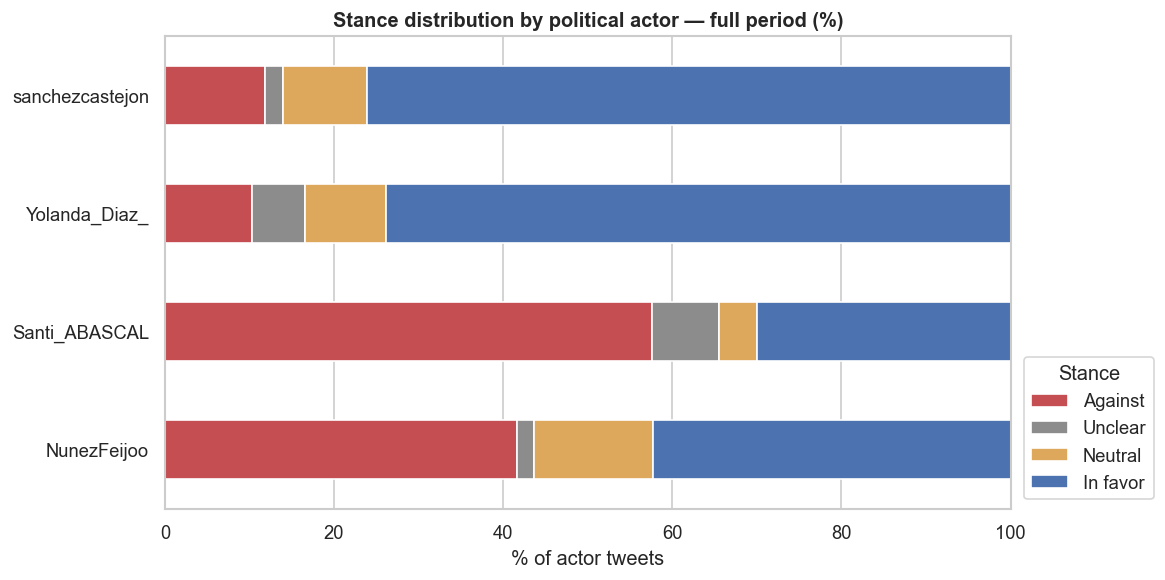

In [40]:
actor_stance_percent = pd.crosstab(
    df['politician'], df['stance'], normalize='index') * 100

stance_order = ['Against', 'Unclear', 'Neutral', 'In favor']

fig, ax = plt.subplots(figsize=(10, 5))
(actor_stance_percent[stance_order]
    .plot.barh(stacked=True, ax=ax,
               color=[STANCE_COLORS[c] for c in stance_order],
               edgecolor='white'))
ax.set_title('Stance distribution by political actor — full period (%)',
             fontweight='bold')
ax.set_xlabel('% of actor tweets'); ax.set_ylabel('')
ax.legend(title='Stance', loc='lower right', bbox_to_anchor=(1.18, 0))
ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()


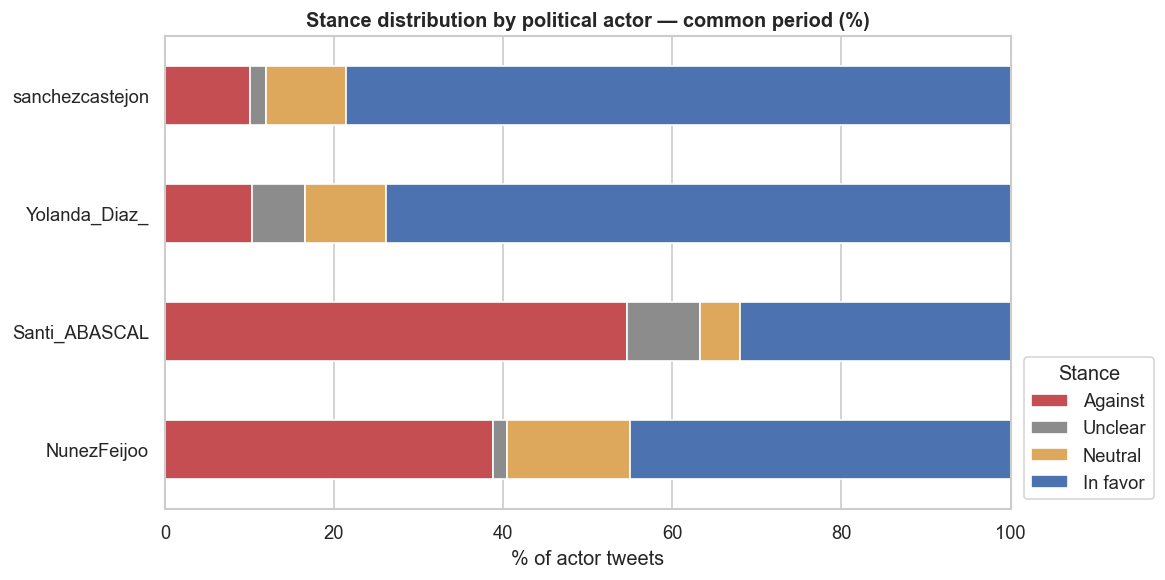

In [41]:
actor_stance_percent_common = pd.crosstab(
    df_common['politician'], df_common['stance'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
(actor_stance_percent_common[stance_order]
    .plot.barh(stacked=True, ax=ax,
               color=[STANCE_COLORS[c] for c in stance_order],
               edgecolor='white'))
ax.set_title('Stance distribution by political actor — common period (%)',
             fontweight='bold')
ax.set_xlabel('% of actor tweets'); ax.set_ylabel('')
ax.legend(title='Stance', loc='lower right', bbox_to_anchor=(1.18, 0))
ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()


The stacked bar charts compare the stance distribution of each political actor in the full period and in the common period. Each bar sums to 100%, so the figure shows the internal stance profile of each actor independently of how many tweets they published.

The main pattern is the clear difference between government-side actors and opposition actors. Sánchez and Yolanda Díaz have a much larger share of tweets classified as In favor, while Feijóo and Abascal have a much larger share of tweets classified as Against. This suggests that stance is strongly related to political role: actors in government tend to use X to promote policies, defend achievements or support institutional action, while opposition actors use it more frequently to criticize the government, its policies or other political actors.

Sánchez shows the most positive stance profile. In both the full period and the common period, most of his tweets are classified as In favor. The share of Against tweets is comparatively low. This is consistent with a communication strategy based on policy promotion, institutional messaging and positive framing of government action.

Yolanda Díaz also presents a strongly positive profile, although with a slightly larger presence of Neutral and Unclear tweets than Sánchez. Her communication is still dominated by In favor, which fits with her role in government and her frequent focus on labour, social policy and rights-related issues.

Feijóo shows a more balanced but clearly oppositional profile. His tweets are split between a large share of Against and a large share of In favor. This suggests that his communication combines criticism of the government with support for his own party proposals, political alternatives or institutional positions. Compared with Abascal, his stance profile is less negative and more mixed.

Abascal has the most critical stance profile. In both periods, Against is the largest category for him. This indicates a strongly oppositional communication style, based mainly on criticism, rejection or confrontation. His share of In favor tweets is much lower than that of Sánchez and Yolanda Díaz.

The comparison between the full period and the common period shows that the main stance patterns remain stable. Sánchez and Yolanda Díaz remain mostly positive, Abascal remains mostly negative, and Feijóo remains in an intermediate position. There are some small changes, but they do not alter the main interpretation. This means that the stance profiles are not mainly caused by the different temporal coverage of the actors.

In short, these charts show that stance is not evenly distributed across politicians. The corpus contains a clear government-opposition divide: Sánchez and Yolanda Díaz mainly communicate in supportive terms, while Feijóo and especially Abascal use a more critical stance. This result is important because it shows that the global stance distribution hides strong actor-level differences.

### Positivity index

A compact summary of each actor's stance lean over the common period,
computed as the difference between the percentages of `In favor` and
`Against` tweets. Positive values indicate an overall affirmative
posture; negative values indicate a predominantly oppositional posture.


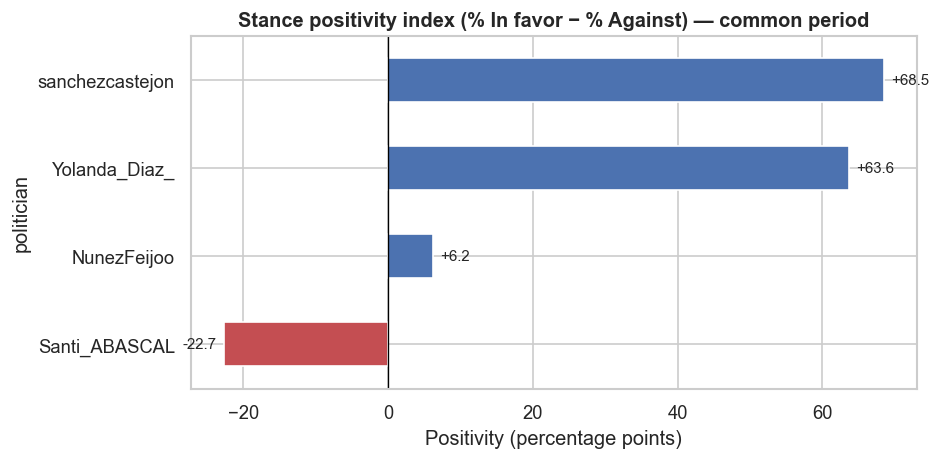

In [42]:
positivity = (actor_stance_percent_common['In favor']
              - actor_stance_percent_common['Against']).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors_pos = ['#C44E52' if v < 0 else '#4C72B0' for v in positivity]
positivity.plot.barh(ax=ax, color=colors_pos, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Stance positivity index (% In favor − % Against) — common period',
             fontweight='bold')
ax.set_xlabel('Positivity (percentage points)')
for i, v in enumerate(positivity):
    ax.text(v + (1 if v >= 0 else -1), i, f'{v:+.1f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()


The figure summarizes the balance between supportive and critical tweets during the common period. The positivity index is calculated as the percentage of In favor tweets minus the percentage of Against tweets.

Sánchez (+68.5 pp) and Yolanda Díaz (+63.6 pp) show strongly positive values, indicating that their communication is mainly supportive. Feijóo is close to balance but slightly positive (+6.2 pp), which reflects a mixed profile combining criticism with support for his own positions. Abascal is the only actor with a negative value (-22.7 pp), confirming a predominantly critical or oppositional communication style.


## The `Other` category

`Other` is the residual topic in the coding guide. Its share of the
corpus and the kinds of tweets it absorbs are reported here because the
category played a central role in the gold standard evaluation
(Chapter 5), where it was the largest source of model–annotator
disagreement.


In [43]:
other_df = df[df['topic'] == 'Other']
print(f'Tweets labelled Other: {len(other_df):,} '
      f'({len(other_df)/len(df)*100:.2f}% of corpus)')

other_by_actor = (other_df['politician'].value_counts(normalize=True) * 100).round(1)
print('\nDistribution by actor (%):')
print(other_by_actor.to_string())

print('\nSample of Other tweets:')
sample_cols = [c for c in ['tweet', 'stance', 'short_justification'] if c in other_df.columns]
other_df[sample_cols].sample(min(10, len(other_df)), random_state=42)


Tweets labelled Other: 1,576 (13.28% of corpus)

Distribution by actor (%):
politician
Yolanda_Diaz_      31.2
sanchezcastejon    28.4
NunezFeijoo        28.0
Santi_ABASCAL      12.4

Sample of Other tweets:


,tweet,stance,short_justification
9666,Emotiva e impresionante. La vida de Lorca sobr...,Unclear,Review of a theatrical performance.
6279,Hoxe perdemos a un loitador incansable pola de...,Neutral,Tribute to a deceased labor activist; expresse...
9149,Emocionado paseo por la ciudad vieja de Quito ...,Neutral,Personal observation about a visit to Quito.
4033,#EuropaVIVA24 #VOX #Viva24,Unclear,"Contains only hashtags, no clear opinion expre..."
3573,Esta tarde a las 20 horas en Mérida #Mérida #V...,Unclear,Informational post about a campaign event.
11570,Vuelvo a hacer un llamamiento a la precaución....,Neutral,Warning about wildfire risks and gratitude to ...
3666,Orgullosos de nuestras Fuerzas Armadas. Orgull...,In favor,Expresses pride in Spanish history and institu...
1559,He venido a Valencia para agradecer a los bomb...,Neutral,Expresses gratitude to emergency workers and l...
3449,¡Gracias Cartagena!#Cartagena #CuidaLotuyo#VOX...,Unclear,Expression of gratitude for a campaign event.
229,Bona Diada. Feliz día de Cataluña a todos.,Neutral,A standard holiday greeting.


The `Other` category represents tweets that could not be clearly assigned to one of the six substantive policy areas. Its distribution is not uniform across actors: Yolanda Díaz accounts for 31.2% of the tweets classified as `Other`, followed by Sánchez with 28.4%, Feijóo with 28.0% and Abascal with 12.4%.

The sample of tweets shows that this category contains several types of content. Some tweets are personal, symbolic or commemorative, such as tributes, cultural references, greetings or expressions of gratitude. Others are informational posts about campaign events, public appearances or short messages containing only hashtags. There are also messages related to emergencies, institutional ceremonies or general public appeals.

This confirms that `Other` works as a residual but necessary category. It prevents the model from forcing tweets into policy categories when the content does not clearly match them. For example, tweets about cultural events, holiday greetings, campaign slogans or generic expressions of gratitude do not fit well into categories such as Economy, Welfare, International Affairs or Immigration.

The stance labels inside `Other` are also mixed. Many examples are classified as `Neutral` or `Unclear`, which is expected because these tweets often do not express a clear political position. However, some tweets can still be classified as `In favor` when they express explicit support, pride or positive evaluation.

In short, the `Other` category captures non-policy or weakly thematic communication. Although it should not be interpreted as a coherent political topic, it is useful for maintaining classification quality and avoiding artificial assignments to substantive categories.

## Summary

The descriptive analysis of the corpus leads to four main conclusions.

First, the corpus is strongly centered on national political debate. National Politics and Governance is the dominant topic, representing 36.8% of all tweets, followed by Economy and Employment (17.2%) and International Affairs (14.7%). This confirms that the dataset captures a political communication environment mainly structured around institutional politics, government activity, party competition and major public issues. The stance distribution is also asymmetric: In favor is the most frequent label (58.0%), followed by Against (27.7%), while Neutral and Unclear together account for a smaller share of the corpus. This suggests that most tweets contain an identifiable political position, often linked to policy promotion, criticism or support for specific political actions.

Second, the four political actors are all well represented, but they do not have identical activity levels or temporal coverage. Yolanda Díaz is the most represented actor in absolute volume, followed by Sánchez, Feijóo and Abascal. However, Yolanda Díaz stops posting on X in January 2025, while the other actors continue to publish after that date. This creates an imbalance in the later part of the corpus. For this reason, a common observation window was defined from 2022-04-23 to 2025-01-21, covering 83.5% of the full dataset. Descriptive volume analyses can use the full corpus, but cross-actor comparisons are preferably based on this common period to ensure fairer comparison.

Third, the actor-level topic matrices reveal clear and stable agenda differences. Feijóo and Abascal concentrate more than half of their tweets in National Politics and Governance, showing a strong focus on institutional conflict, government criticism and national political debate. Yolanda Díaz presents a different profile, with Economy and Employment as her main category, consistent with a socio-economic and labour-oriented agenda. Sánchez shows a more diversified profile, with a particularly strong presence of International Affairs, consistent with his role as head of government. These patterns remain very similar when comparing the full period with the common period, which indicates that the main actor-topic profiles are robust and not mainly caused by unequal temporal coverage.

Fourth, the Jensen-Shannon distance matrix confirms that agenda similarity follows a politically meaningful bloc structure. The closest pair is Sánchez and Yolanda Díaz (JSD = 0.217), followed by Feijóo and Abascal (JSD = 0.227). In contrast, the largest divergence appears between Abascal and Yolanda Díaz (JSD = 0.448). This structure emerges only from topic distributions, without using party affiliation or ideological labels. Therefore, the thematic agenda of each actor is not random: it reflects clear differences in political priorities and communication strategies.

Fifth, stance distributions reveal a different but complementary structure. Sánchez and Yolanda Díaz show strongly positive stance balances during the common period, with positivity indexes of +68.5 and +63.6 percentage points, respectively. Feijóo remains close to balance (+6.2), while Abascal is the only actor with a negative balance (-22.7). This suggests that stance is more closely related to institutional role than topic agenda. Government-side actors tend to communicate in supportive terms, while opposition actors, especially Abascal, use a more critical stance. The global stance distribution therefore hides important actor-level differences.

Finally, the `Other` category confirms the need for a residual class in the classification schema. This category contains heterogeneous tweets that do not clearly fit into the substantive policy areas, such as greetings, tributes, campaign event announcements, cultural references, symbolic messages or short hashtag-based posts. Its presence helps avoid forcing ambiguous or non-policy content into inappropriate categories. For this reason, `Other` should not be interpreted as a coherent political topic, but as a useful control category that improves the quality and interpretability of the classification.
